In [13]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
import json
from langchain_core.messages import AIMessage
from Prediction_Helper import disease_Detection
from generation import generate_answer

In [14]:
class State(TypedDict):
    messages: Annotated[list, add_messages]
    image_path: str | None
    disease: str | None
    rag_context: str | None
    response: dict | None

In [15]:
def router_request(state: State):

    if state.get("image_path"):
        return "diseaseDetect"

    return "ragChatbot"

In [16]:
def disease_Detector(state: State):
    image_path = state.get("image_path")

    if not image_path:
        return {
            "disease": None
        }

    disease = disease_Detection(image_path)

    return{
        "disease": disease
    }


    

In [17]:
test_state = {
    "messages": [],
    "image_path": r"D:\rag chatbot\disease_detection\IMAGE dATASET\Banana_Sigatoka\0.jpeg",
    "disease": None,
    "rag_context": None,
    "response": None
}

result = disease_Detector(test_state)

print(result)

{'disease': 'Banana_Sigatoka'}


In [18]:
def ragChatbot(state: State):

    messages = state["messages"]

    # Current user question
    user_query = messages[-1].content

    disease = state.get("disease")

    # ------------------------------------------------
    # Build conversation history
    # ------------------------------------------------

    history = []

    for message in messages[:-1]:

        role = "User" if message.type == "human" else "Assistant"

        history.append(
            f"{role}: {message.content}"
        )

    conversation_history = "\n".join(history)

    # ------------------------------------------------
    # Generate response
    # ------------------------------------------------

    result = generate_answer(
        question=user_query,
        disease=disease,
        conversation_history=conversation_history
    )

    response = result["response"]

    # ------------------------------------------------
    # Store assistant response in messages
    # ------------------------------------------------

    assistant_message = AIMessage(
        content=json.dumps(
            response,
            ensure_ascii=False
        )
    )

    return {
        "messages": [assistant_message],
        "rag_context": result["context"],
        "response": response
    }

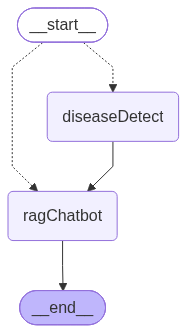

In [19]:
graph = StateGraph(State)

### Nodes
graph.add_node("diseaseDetect", disease_Detector)
graph.add_node("ragChatbot", ragChatbot)

### Edges

graph.add_conditional_edges(
    START,
    router_request,
    {
        "diseaseDetect": "diseaseDetect",
        "ragChatbot": "ragChatbot"
    }
)

graph.add_edge("diseaseDetect", "ragChatbot")
graph.add_edge("ragChatbot", END)

memory = MemorySaver()
app = graph.compile(
    checkpointer=memory
)
app

In [20]:
import inspect
print(inspect.signature(generate_answer))

(question: str, disease: str | None = None, conversation_history: str = '')


In [21]:
from langchain_core.messages import HumanMessage

test_state = {
    "messages": [
        HumanMessage(
            content="What disease does this plant have and how should I treat it?"
        )
    ],
    "image_path": r"D:\rag chatbot\disease_detection\IMAGE dATASET\Banana_Sigatoka\0.jpeg",
    "disease": None,
    "rag_context": None,
    "response": None
}

config = {
    "configurable": {
        "thread_id": "test-session-1"
    }
}

result = app.invoke(
    test_state,
    config=config
)

print(result)

{'messages': [HumanMessage(content='What disease does this plant have and how should I treat it?', additional_kwargs={}, response_metadata={}, id='9830b0b9-f70b-4a7b-8746-babb7f31697d'), AIMessage(content='{"disease": "Banana Sigatoka (leaf spot disease)", "symptoms": "Severely affected leaves showing initial symptoms of leaf spot.", "causes": "Information not available in the knowledge base.", "treatment": "Cut and remove severely affected leaves and spray 1% Bordeaux mixture with sticker soon after initial symptoms; repeat after 3 weeks if infestation persists. Additionally, spray 0.5\u202fml Propiconazole 25\u202fEC + 1% mineral oil per litre of water.", "prevention": "Information not available in the knowledge base."}', additional_kwargs={}, response_metadata={}, id='77725428-3e54-492d-a7b1-eb19009de693', tool_calls=[], invalid_tool_calls=[])], 'image_path': 'D:\\rag chatbot\\disease_detection\\IMAGE dATASET\\Banana_Sigatoka\\0.jpeg', 'disease': 'Banana_Sigatoka', 'rag_context': ".

In [22]:
config = {
    "configurable": {
        "thread_id": "test-session-1"
    }
}

result = app.invoke(
    test_state,
    config=config
)

print("Detected Disease:")
print(result["disease"])

print("\nStructured Response:")
print(result["response"])

Detected Disease:
Banana_Sigatoka

Structured Response:
{'disease': 'Banana Sigatoka', 'symptoms': 'Information not available in the knowledge base.', 'causes': 'Information not available in the knowledge base.', 'treatment': 'Cut and remove severely affected leaves and spray 1% Bordeaux mixture with sticker soon after initial symptoms; repeat after 3 weeks if infestation persists. Also spray 0.5\u202fml Propiconazole 25\u202fEC + 1% mineral oil per litre of water. Additionally, apply quinalphos 0.05% or chlorpyrifos 0.03% and repeat after 3 weeks if infestation persists.', 'prevention': 'Information not available in the knowledge base.'}


In [23]:
from langchain_core.messages import HumanMessage

test_state = {
    "messages": [
        HumanMessage(
            content="isse kaise theek kare?"
        )
    ],
    "image_path": None,
    "disease": None,
    "rag_context": None,
    "response": None
}

config = {
    "configurable": {
        "thread_id": "test-session-1"
    }
}

result = app.invoke(
    test_state,
    config=config
)

print(result)

{'messages': [HumanMessage(content='What disease does this plant have and how should I treat it?', additional_kwargs={}, response_metadata={}, id='9830b0b9-f70b-4a7b-8746-babb7f31697d'), AIMessage(content='{"disease": "Banana Sigatoka (leaf spot disease)", "symptoms": "Severely affected leaves showing initial symptoms of leaf spot.", "causes": "Information not available in the knowledge base.", "treatment": "Cut and remove severely affected leaves and spray 1% Bordeaux mixture with sticker soon after initial symptoms; repeat after 3 weeks if infestation persists. Additionally, spray 0.5\u202fml Propiconazole 25\u202fEC + 1% mineral oil per litre of water.", "prevention": "Information not available in the knowledge base."}', additional_kwargs={}, response_metadata={}, id='77725428-3e54-492d-a7b1-eb19009de693', tool_calls=[], invalid_tool_calls=[]), AIMessage(content='{"disease": "Banana Sigatoka", "symptoms": "Information not available in the knowledge base.", "causes": "Information not

In [24]:
next_state = {
    "messages": [HumanMessage(content="what about prevention for next season?")],
    "image_path": None,
    "disease": None,
    "rag_context": None,
    "response": None
}
result = app.invoke(next_state, config=config)
print(result["response"])

{'topic': 'Banana Sigatoka disease prevention', 'answer': 'Apply a 1\u202f% Bordeaux mixture with sticker as a prophylactic spray early in the season, especially on new leaves and spindle leaves; treat planting suckers with Mancozeb (3\u202fg\u202fL⁻¹) and Monocrotophos (2\u202fml\u202fL⁻¹) and apply Trichoderma viride (5\u202fkg) plus FYM (100\u202fkg) to reduce soil‑borne inoculum; maintain proper irrigation during fruit development; remove any severely affected leaves promptly to reduce inoculum load.', 'recommendations': '- Spray 1\u202f% Bordeaux mixture on young leaves and neighboring palms before disease onset.\n- At planting, dip suckers in Mancozeb and Monocrotophos, then coat rhizomes with Trichoderma viride and FYM.\n- Ensure adequate irrigation at fruit development stage.\n- Regularly scout and prune diseased foliage.', 'precautions': 'Use protective gear when handling chemicals; follow recommended concentrations; repeat Bordeaux spray only after 3\u202fweeks if symptoms ap

In [26]:
from langchain_core.messages import HumanMessage

test_state = {
    "messages": [
        HumanMessage(
            content="What disease does this plant have and how should I treat it?"
        )
    ],
    "image_path": r"D:\rag chatbot\disease_detection\IMAGE dATASET\Apple___healthy\00a6039c-e425-4f7d-81b1-d6b0e668517e___RS_HL 7669.JPG",
    "disease": None,
    "rag_context": None,
    "response": None
}

config = {
    "configurable": {
        "thread_id": "test-session-1"
    }
}

result = app.invoke(
    test_state,
    config=config
)

print(result)

{'messages': [HumanMessage(content='What disease does this plant have and how should I treat it?', additional_kwargs={}, response_metadata={}, id='9830b0b9-f70b-4a7b-8746-babb7f31697d'), AIMessage(content='{"disease": "Banana Sigatoka (leaf spot disease)", "symptoms": "Severely affected leaves showing initial symptoms of leaf spot.", "causes": "Information not available in the knowledge base.", "treatment": "Cut and remove severely affected leaves and spray 1% Bordeaux mixture with sticker soon after initial symptoms; repeat after 3 weeks if infestation persists. Additionally, spray 0.5\u202fml Propiconazole 25\u202fEC + 1% mineral oil per litre of water.", "prevention": "Information not available in the knowledge base."}', additional_kwargs={}, response_metadata={}, id='77725428-3e54-492d-a7b1-eb19009de693', tool_calls=[], invalid_tool_calls=[]), AIMessage(content='{"disease": "Banana Sigatoka", "symptoms": "Information not available in the knowledge base.", "causes": "Information not